# DSS demonstration
Access to notebook: https://github.com/openalea/DSS/blob/master/example/DSS_demonstration.ipynb

In [2]:
from openalea.weatherdata.ipm import WeatherDataHub
from openalea.dss import Manager as ModelManager


# Acces to IPM DSS from OpenAlea python

## 1. Access to dss catalog 

In [3]:
h = ModelManager()
h.display()


dss               models     pests  \
0                 uk.WarwickHRI    LAMTEQ_WarwickHRI  [LAMTEQ]   
1                 uk.WarwickHRI    MELIAE_WarwickHRI  [MELIAE]   
2                 uk.WarwickHRI    HYLERA_WarwickHRI  [HYLERA]   
3                 uk.WarwickHRI    PSILRO_WarwickHRI  [PSILRO]   
4                 uk.WarwickHRI  it_horta_dss_tomato       NaN   
..                          ...                  ...       ...   
970  AHDB.OSR_disease_forecasts               RHYNSE       NaN   
971  AHDB.OSR_disease_forecasts               PUCCHD       NaN   
972  AHDB.OSR_disease_forecasts        SlugWatch2023       NaN   
973  AHDB.OSR_disease_forecasts               SCLESC  [SCLESC]   
974  AHDB.OSR_disease_forecasts               LEPTMA  [LEPTMA]   

                            crops  \
0                         [NARSS]   
1           [BRSOB, BRSOK, BRSNN]   
2                         [BRSSS]   
3    [DAUCS, PAVSA, APUGR, PARCR]   
4                             NaN   
..                            ...   
970                           NaN   
971                           NaN   
972                           NaN   
973                       [BRSNN]   
974                       [BRSNN]   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

### 2.1 select dss and model

In [4]:
psitemp=h.get_model("no.nibio.vips", "PSILARTEMP")

### 2.2 display meta-information of dss model

In [5]:
psitemp.informations("dataframe")



,name,id,description,type_of_decision,pests,crops,weather input,field_observation input,output,output_description
0,Carrot fly flight model,PSILARTEMP,"THE PEST: The first generation of adult carrot fly emerge from pupae in the soil in the spring, and lay eggs close to the base of vulnerable crops. Larvae initial feed at the surface, then tunnel into the tap root. Adults emerge mid-July and can lead to a second generation. \nTHE DECISION: Treatments may need to be applied soon after adults arrive in the crop, before larvae tunnel into the crop roots. \nTHE MODEL: The model determines the start of the flight period for the 1st generation of carrot rust fly based on accumuleted degree-days (260 day-degrees) over a base temperature of 5°C. \nTHE PARAMETERS: The model uses daily air temperature \nSOURCE: Luke, Finland. \nASSUMPTIONS: Be aware that in areas with field covers (plastic, single or double non-woven covers, etc.) with early crops the preceding season (either on the current field or neighboring fields), the flight period can start earlier than predicted due to higher soil temperature under the covers.\nREFERENCE: Marjjula et al 2000\n",Short-term tactical,[PSILRO],[DAUCS],1002,None,"TMDD5C, THRESHOLD_1, THRESHOLD_2, THRESHOLD_3","Accumulated day degrees, Threshold for start of flight period, Threshold for peak flight period, Threshold for end of 1st generation flight period"


### 2.3 import IPM weatherdata or local OpenAlea ressouce from local IPM catalog

In [6]:
ws=WeatherDataHub()
slu=ws.get_ressource('se.slu.lantmet')

weather=slu.data(parameters=[1002],latitude=[67.28],longitude=[14.37],
                 timeStart='2021-06-01',timeEnd="2021-08-20",timeZone="Europe/Paris",
                 display="json")

### 2.4 Run model and vizualise

* run model

In [7]:
ds=psitemp.run(weatherdata=weather)
ds

<xarray.Dataset> Size: 3kB
Dimensions:      (time: 81)
Coordinates:
  * time         (time) datetime64[us] 648B 2021-05-31 2021-06-01 ... 2021-08-19
Data variables:
    TMDD5C       (time) float64 648B 8.73 16.16 25.07 ... 1.037e+03 1.047e+03
    THRESHOLD_1  (time) float64 648B 260.0 260.0 260.0 ... 260.0 260.0 260.0
    THRESHOLD_2  (time) float64 648B 360.0 360.0 360.0 ... 360.0 360.0 360.0
    THRESHOLD_3  (time) float64 648B 560.0 560.0 560.0 ... 560.0 560.0 560.0
Attributes:
    name:             Carrot fly flight model
    id:               PSILARTEMP
    version:          1.0
    authors:          {'name': '', 'email': 'vips@nibio.no', 'organization': ...
    description:      THE PEST: The first generation of adult carrot fly emer...
    description_url:  https://www.vips-landbruk.no/forecasts/models/PSILARTEMP/

* plot output

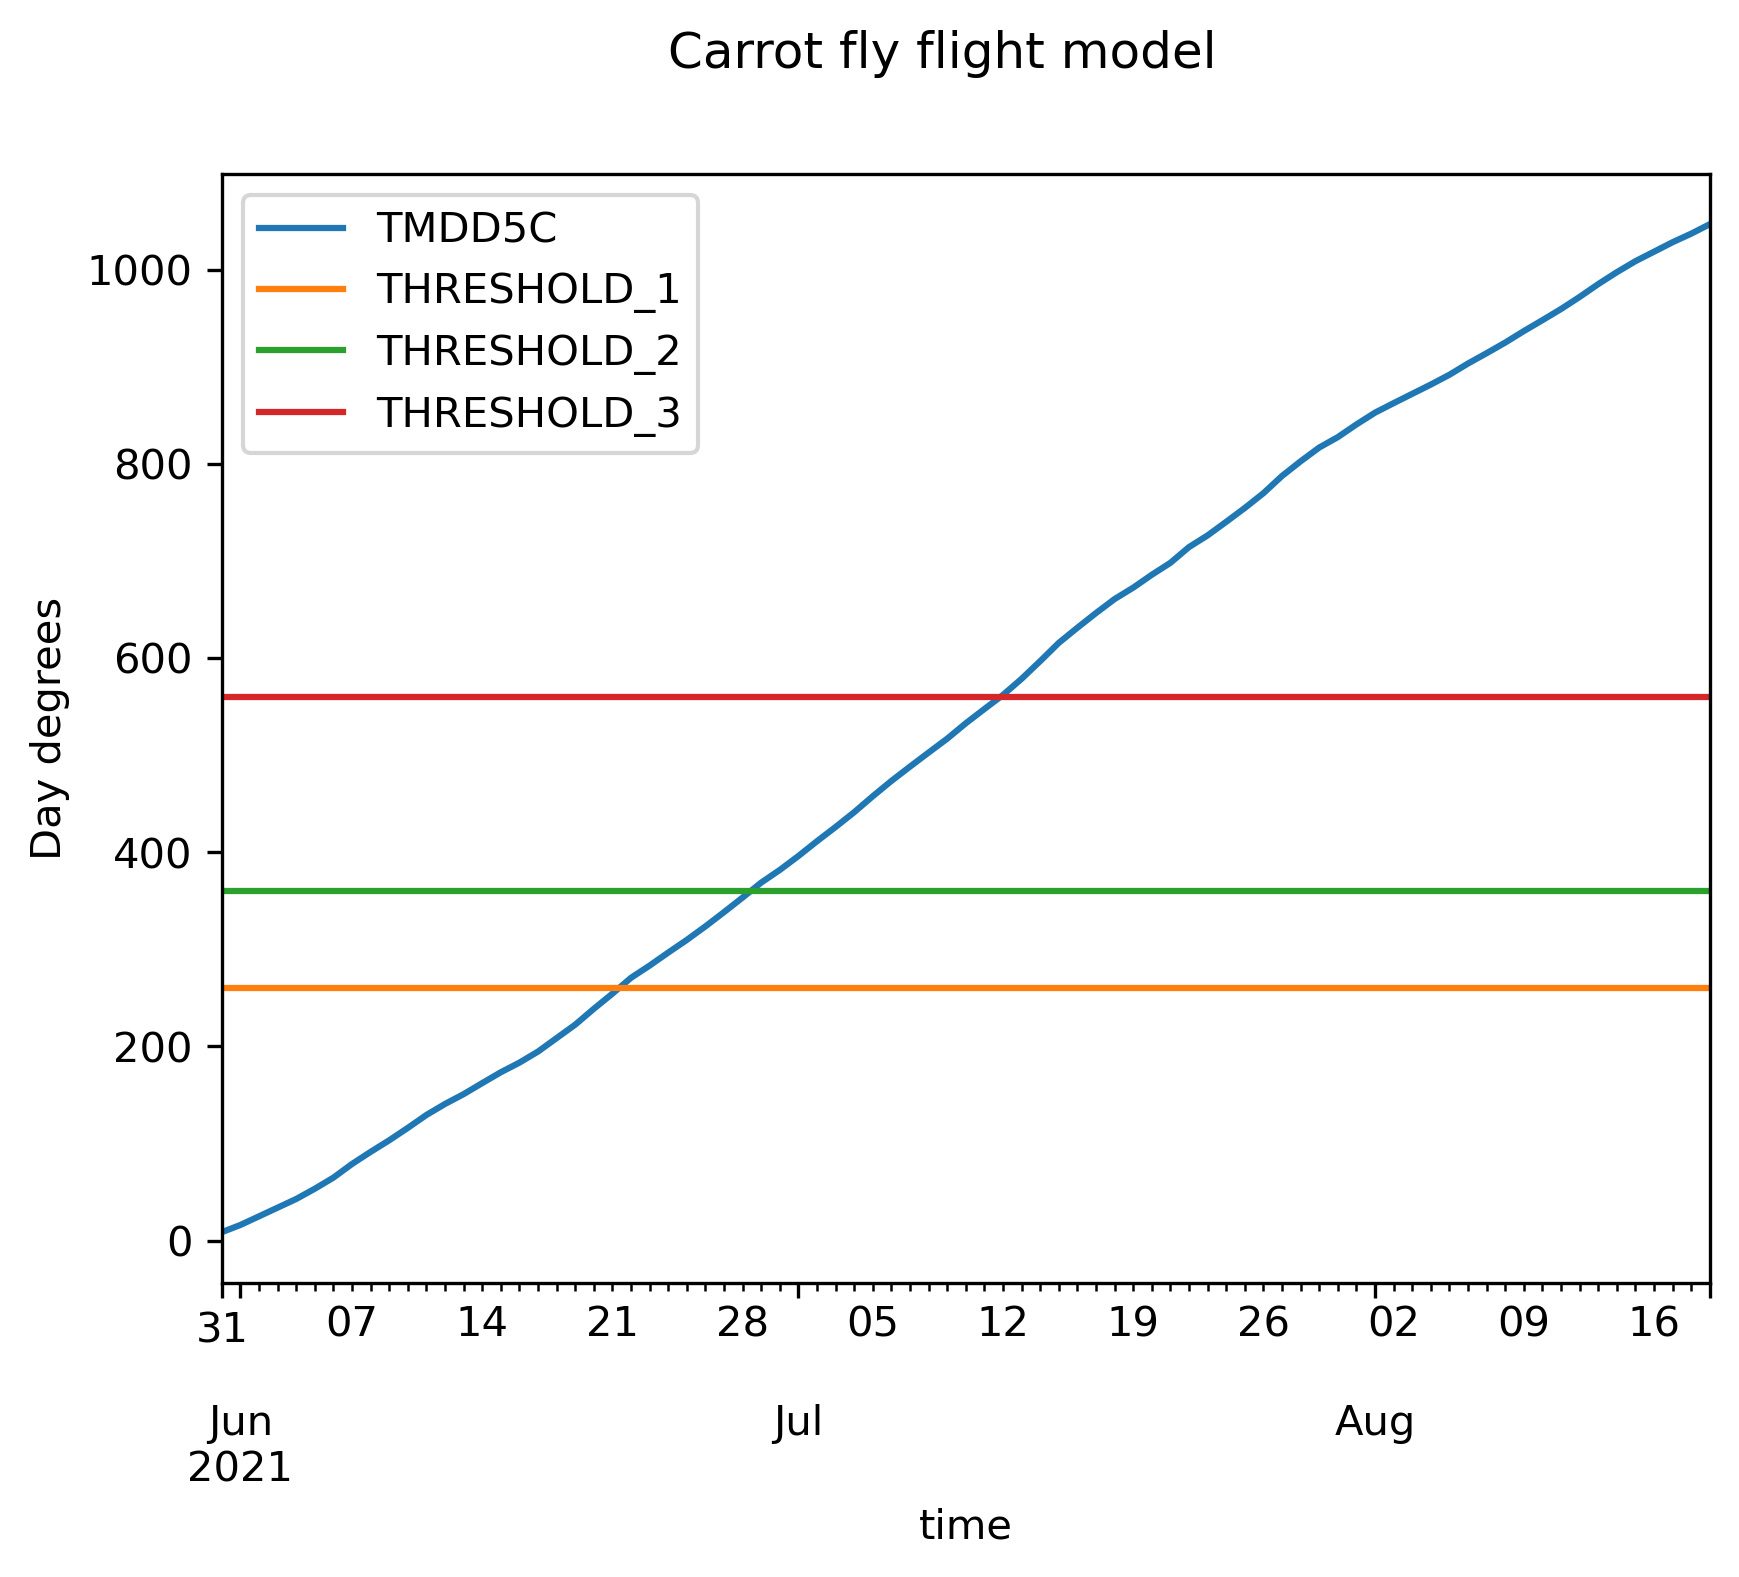

In [8]:
psitemp.plot(ds)

In [1]:
import pandas
import matplotlib.pyplot as plt
import numpy

pandas.set_option('display.max_rows',10)
pandas.set_option('display.max_colwidth',None)

plt.rcParams['figure.dpi'] = 300 #dpi
plt.rcParams['savefig.dpi'] = 300